<a href="https://colab.research.google.com/github/MayerT1/LiDAR_Dev/blob/main/Sewanee_Lidar_ALS_9_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
    from google.colab import drive
    drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
!pip install laspy pyproj open3d plotly

In [14]:
import laspy
from pyproj import CRS
import os
import requests
import numpy as np
import matplotlib.pyplot as plt
import glob
import shutil
import plotly.graph_objects as go
import pandas as pd
import glob
from shapely.geometry import Point
import geopandas as gpd

# LAS Download

zenodo fetch: https://zenodo.org/records/16906266

In [4]:

# Create a local folder to store LAS files
os.makedirs("/content/data", exist_ok=True)

# ✅ Full list of available LAS files from Zenodo
las_filenames = ["1982317NW.las"]


    # "1954285NE.las", "1954285SE.las",
    # "1954293NE.las", "1954293SE.las",
    # "1954301NE.las", "1954301SE.las",
    # "1954309NE.las", "1954309SE.las",
    # "1954317NE.las", "1954317SE.las",
    # "1954325NE.las", "1954325SE.las",

    # "1968285NE.las","1968285NW.las","1968285SE.las","1968285SW.las",
    # "1968293NE.las","1968293NW.las","1968293SE.las","1968293SW.las",
    # "1968301NE.las","1968301NW.las","1968301SE.las","1968301SW.las",
    # "1968309NE.las","1968309NW.las","1968309SE.las","1968309SW.las",
    # "1968317NE.las","1968317NW.las","1968317SE.las","1968317SW.las",
    # "1968325NE.las","1968325NW.las","1968325SE.las","1968325SW.las",

    # "1982285NE.las","1982285NW.las","1982285SE.las","1982285SW.las",
    # "1982293NW.las","1982293SE.las","1982293SW.las",
    # "1982301NE.las","1982301SE.las","1982301SW.las",
    # "1982309NE.las","1982309NW.las","1982309SE.las","1982309SW.las",
    # "1982317NE.las","1982317NW.las","1982317SE.las","1982317SW.las",
    # "1982325NE.las","1982325SW.las",

    # "1996285SW.las","1996293NW.las","1996293SW.las",
    # "1996301NW.las","1996301SW.las",
    # "1996309SW.las","1996317SW.las","1996325NW.las"
# ]

# Zenodo record base URL
base_url = "https://zenodo.org/records/16906266/files"

def download_las(filename, folder="/content/data"):
    """Download a LAS file from Zenodo if not already present"""
    local_path = os.path.join(folder, filename)
    if not os.path.exists(local_path):
        url = f"{base_url}/{filename}?download=1"
        print(f"⬇️ Downloading {filename} ...")
        r = requests.get(url, stream=True)
        if r.status_code == 200:
            with open(local_path, "wb") as f:
                for chunk in r.iter_content(chunk_size=8192):
                    f.write(chunk)
        else:
            raise Exception(f"Failed to download {filename}: {r.status_code}")
    else:
        print(f"✅ Already downloaded: {filename}")
    return local_path

# Download a *subset* (all 72 will be very heavy in Colab!)
subset = las_filenames[:72]  # grab the first 6 for testing
local_files = [download_las(fn) for fn in subset]

print(f"Downloaded {len(local_files)} LAS files to /content/data")


⬇️ Downloading 1982317NW.las ...
Downloaded 1 LAS files to /content/data


In [12]:

las_path = "/content/data/1982317NW.las"

# Open LAS file
las = laspy.read(las_path)

# Get CRS info (if available in the file header)
if las.header.parse_crs() is not None:
    crs = las.header.parse_crs()
    print("CRS (WKT):", crs.to_wkt())
    print("CRS (EPSG):", crs.to_epsg())
else:
    print("❌ No CRS information found in the LAS header.")

CRS (WKT): COMPOUNDCRS["NAD83(2011) / Tennessee (ftUS) / NAVD88 height - Geoid12B (ftUS)",PROJCRS["NAD83(2011) / Tennessee (ftUS)",BASEGEOGCRS["NAD83(2011)",DATUM["NAD83 (National Spatial Reference System 2011)",ELLIPSOID["GRS 1980",6378137,298.257222101,LENGTHUNIT["metre",1]]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],ID["EPSG",6318]],CONVERSION["unnamed",METHOD["Lambert Conic Conformal (2SP)",ID["EPSG",9802]],PARAMETER["Latitude of 1st standard parallel",36.4166666666667,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8823]],PARAMETER["Latitude of 2nd standard parallel",35.25,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8824]],PARAMETER["Latitude of false origin",34.3333333333333,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8821]],PARAMETER["Longitude of false origin",-86,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8822]],PARAMETER["Easting at false origin",1968500,LENGTHUNIT["US survey foot",0.304800609601219],ID["EPSG",8826]],PARAMETER["Northing at 

# Plot all LiDAR

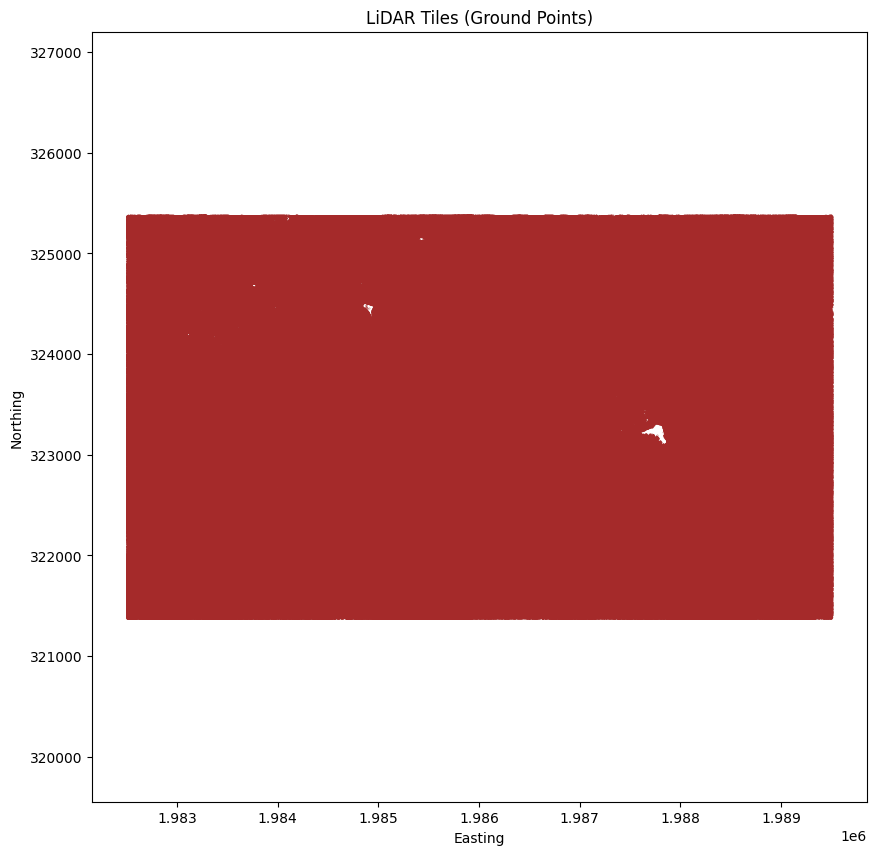

In [5]:

# Function to read LAS and extract XY points (optionally filtering to ground points)
def read_las_xy(filename, ground_only=True):
    las = laspy.read(filename)
    x = las.x
    y = las.y

    if ground_only and "classification" in las.point_format.dimension_names:
        mask = las.classification == 2  # 2 = ground
        x = x[mask]
        y = y[mask]

    return x, y

# Aggregate points from all LAS tiles
all_x, all_y = [], []
for f in local_files:
    try:
        x, y = read_las_xy(f, ground_only=True)
        all_x.append(x)
        all_y.append(y)
    except Exception as e:
        print(f"⚠️ Skipping {f}: {e}")

all_x = np.concatenate(all_x)
all_y = np.concatenate(all_y)

# Quick visualization
plt.figure(figsize=(10, 10))
plt.scatter(all_x, all_y, s=0.1, c="brown", alpha=0.6)
plt.title("LiDAR Tiles (Ground Points)")
plt.xlabel("Easting")
plt.ylabel("Northing")
plt.axis("equal")
plt.show()


In [6]:

# Path to local folder where .las files are stored
folder = "/content/data"

# Get all LAS files (case-insensitive)
las_files = glob.glob(f"{folder}/*.las") + glob.glob(f"{folder}/*.LAS")
print(f"Found {len(las_files)} LAS files")

# ---------------------------
# Step 1: Load LAS data (with sampling + copy to local)
# ---------------------------
points = []
intensity = []

def load_las_points(filepath, n_points=50000):
    """Copy LAS file locally, read with laspy, return sampled xyz + intensity."""
    local_file = "/content/temp.las"
    shutil.copy(filepath, local_file)
    las = laspy.read(local_file)

    xyz = np.vstack((las.x, las.y, las.z)).T
    intens = las.intensity

    # Random sampling
    if xyz.shape[0] > n_points:
        idx = np.random.choice(xyz.shape[0], n_points, replace=False)
        xyz = xyz[idx]
        intens = intens[idx]

    return xyz, intens

for i, file in enumerate(las_files):
    print(f"Loading {i+1}/{len(las_files)}: {os.path.basename(file)}")
    try:
        xyz, intens = load_las_points(file, n_points=30000)
        points.append(xyz)
        intensity.append(intens)
    except Exception as e:
        print(f"❌ Failed to load {file}: {e}")

points = np.vstack(points)
intensity = np.hstack(intensity)
z_values = points[:, 2]

print("Loaded points:", points.shape)
print("Intensity range:", intensity.min(), "-", intensity.max())
print("Z (elevation) range:", z_values.min(), "-", z_values.max())

# ---------------------------
# Step 2: Downsample (across all files, for plotting speed)
# ---------------------------
max_points = 100000  # adjust for responsiveness
if points.shape[0] > max_points:
    sample_idx = np.random.choice(points.shape[0], size=max_points, replace=False)
    sample_points = points[sample_idx]
    sample_intensity = intensity[sample_idx]
    sample_z = z_values[sample_idx]
else:
    sample_points, sample_intensity, sample_z = points, intensity, z_values

print("Sample of X:", sample_points[:5,0])
print("Sample of Y:", sample_points[:5,1])
print("Sample of Z:", sample_points[:5,2])
print("Intensity sample:", sample_intensity[:5])
print("Number of points to plot:", sample_points.shape[0])

# ---------------------------
# Step 2.5: Normalize XY for plotting (shift to origin and convert to km)
# ---------------------------
norm_points = sample_points.copy()
norm_points[:, 0] -= norm_points[:, 0].min()
norm_points[:, 1] -= norm_points[:, 1].min()

# optional: scale XY to kilometers for nicer axes
norm_points[:, 0] /= 1000.0
norm_points[:, 1] /= 1000.0

# ---------------------------
# Step 3: Plot function
# ---------------------------
def plot_pointcloud(points, values, title, cmap="Viridis"):
    fig = go.Figure(data=[go.Scatter3d(
        x=points[:,0],
        y=points[:,1],
        z=points[:,2],
        mode='markers',
        marker=dict(
            size=2,
            color=values,
            colorscale=cmap,
            opacity=0.7
        )
    )])

    fig.update_layout(
        scene=dict(
            xaxis_title="X (km)",
            yaxis_title="Y (km)",
            zaxis_title="Z (m)"
        ),
        title=title,
        height=800
    )
    fig.show()

# ---------------------------
# Step 4: Plot by Intensity
# ---------------------------
plot_pointcloud(norm_points, sample_intensity,
                title="Interactive LiDAR Point Cloud (Colored by Intensity, Normalized XY)",
                cmap="Inferno")

# ---------------------------
# Step 5: Plot by Elevation (Z)
# ---------------------------
plot_pointcloud(norm_points, sample_z,
                title="Interactive LiDAR Point Cloud (Colored by Elevation / Z, Normalized XY)",
                cmap="Viridis")


Found 1 LAS files
Loading 1/1: 1982317NW.las
Loaded points: (30000, 3)
Intensity range: 0 - 65535
Z (elevation) range: 1333.1100000000001 - 2020.53
Sample of X: [1985465.77 1988450.62 1982959.88 1985483.2  1985684.7 ]
Sample of Y: [324162.65 323867.9  322540.67 324859.45 322028.38]
Sample of Z: [1929.84 1893.03 1950.72 1967.52 1940.52]
Intensity sample: [ 4725 11025  6720 11550  9450]
Number of points to plot: 30000


# Download GEDI CSV

dataset: https://zenodo.org/records/16929466

In [9]:

record_id = "16929466"
# For restricted access, you'd need an access token
# ACCESS_TOKEN = "YOUR_ZENODO_ACCESS_TOKEN"

# Fetch record metadata to get file links
r = requests.get(f"https://zenodo.org/api/records/{record_id}") # , params={'access_token': ACCESS_TOKEN}
r.raise_for_status()
files = r.json()['files']

# Download each file
for file_info in files:
    filename = file_info['key']
    download_url = file_info['links']['self']

    with requests.get(download_url, stream=True) as r_file:
        r_file.raise_for_status()
        with open(filename, 'wb') as f:
            for chunk in r_file.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f"Downloaded: {filename}")

Downloaded: GEDI_csvs.zip


In [10]:
!unzip /content/GEDI_csvs.zip

Archive:  /content/GEDI_csvs.zip
   creating: GEDI_csvs/.ipynb_checkpoints/
  inflating: GEDI_csvs/PaintRock_AOI_Variables_selected_subset_GEDI02_B.csv  
  inflating: GEDI_csvs/Sewanee_Domain_Variables_selected_subset_GEDI02_B.csv  
  inflating: GEDI_csvs/SPB_AOI_Variables_selected_subset_GEDI02_B.csv  
  inflating: GEDI_csvs/Prescribed_Burn_AOI_Variables_selected_subset_GEDI02_B.csv  


In [21]:

gedi = pd.read_csv("/content/GEDI_csvs/Sewanee_Domain_Variables_selected_subset_GEDI02_B.csv")
# print(gedi.head())

gedi_gdf = gpd.GeoDataFrame(
    gedi,
    geometry=gpd.points_from_xy(gedi['lon'], gedi['lat']),
    crs="EPSG:6576" ### converting to make the particular TN las files "EPSG:4326"  # WGS84
)

# gedi_gdf

# Buffer each point by 25 (units = CRS units, so 25 in EPSG:6576)
gedi_gdf['geometry'] = gedi_gdf.buffer(25)

# Save back if needed
gedi_gdf.to_file("/content/GEDI_csvs/gedi_buffers.geojson", driver="GeoJSON")

# Show first few rows
gedi_gdf.head()

,lat,lon,geolocation/solar_elevation,geolocation/local_beam_elevation,selected_l2a_algorithm,geolocation/degrade_flag,l2b_quality_flag,geolocation/digital_elevation_model,geolocation/elev_lowestmode,geolocation/elev_highestreturn,...,pai_z,fhd_normal,pavd_z,cover,cover_z,product,Beam,fileName,date,geometry
0,35.150719,-85.989317,-31.863182,1.488545,2,0,0,387.710480,383.652985,393.101868,...,"[-9999.0, -9999.0, -9999.0, -9999.0, -9999.0, ...",-9999.000000,"[-9999.0, -9999.0, -9999.0, -9999.0, -9999.0, ...",-9999.000000,"[-9999.0, -9999.0, -9999.0, -9999.0, -9999.0, ...",GEDI_L2B,BEAM0000,GEDI02_B_2022208032656_O20506_03_T10272_02_003...,2022-07-27,"POLYGON ((-60.989 35.151, -61.11 32.7, -61.47 ..."
1,35.150362,-85.988848,-31.863676,1.488545,2,0,0,400.356781,397.770203,403.148224,...,"[-9999.0, -9999.0, -9999.0, -9999.0, -9999.0, ...",-9999.000000,"[-9999.0, -9999.0, -9999.0, -9999.0, -9999.0, ...",-9999.000000,"[-9999.0, -9999.0, -9999.0, -9999.0, -9999.0, ...",GEDI_L2B,BEAM0000,GEDI02_B_2022208032656_O20506_03_T10272_02_003...,2022-07-27,"POLYGON ((-60.989 35.15, -61.109 32.7, -61.469..."
2,35.150007,-85.988381,-31.864174,1.488545,2,0,0,411.618408,408.839966,420.716431,...,"[2.370798349380493, 1.6575210094451904, 0.2299...",2.375521,"[0.14265549182891846, 0.21408478915691376, 0.1...",0.693251,"[0.6932507157325745, 0.5627266764640808, 0.108...",GEDI_L2B,BEAM0000,GEDI02_B_2022208032656_O20506_03_T10272_02_003...,2022-07-27,"POLYGON ((-60.988 35.15, -61.109 32.7, -61.469..."
3,35.149654,-85.987916,-31.864660,1.488545,2,0,1,415.675598,416.459106,423.965942,...,"[0.7661257386207581, 0.27644988894462585, -0.0...",2.014309,"[0.09793517738580704, 0.07661257684230804, 0.0...",0.319441,"[0.3180364668369293, 0.12906767427921295, 0.0,...",GEDI_L2B,BEAM0000,GEDI02_B_2022208032656_O20506_03_T10272_02_003...,2022-07-27,"POLYGON ((-60.988 35.15, -61.108 32.699, -61.4..."
4,35.149297,-85.987447,-31.865154,1.488545,2,0,1,431.158478,431.266815,436.607483,...,"[0.9994505047798157, 0.0428326241672039, -0.0,...",1.702657,"[0.19132357835769653, 0.0999450534582138, 0.00...",0.394094,"[0.392997145652771, 0.02118784375488758, 0.0, ...",GEDI_L2B,BEAM0000,GEDI02_B_2022208032656_O20506_03_T10272_02_003...,2022-07-27,"POLYGON ((-60.987 35.149, -61.108 32.699, -61...."


# bring the GEDI and ALS together

In [16]:
import laspy
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# Load LAS
als_las_path = "/content/data/1982317NW.las"
las = laspy.read(als_las_path)

# Convert to numpy arrays
x = las.x.copy()  # .copy() ensures it's a proper numpy array
y = las.y.copy()
z = las.z.copy()

# Create geometry column
geometry = [Point(xy) for xy in zip(x, y)]

# Create GeoDataFrame
als_gdf = gpd.GeoDataFrame(
    pd.DataFrame({
        'x': x,
        'y': y,
        'z': z
    }),
    geometry=geometry,
    crs=None  # set CRS if known, e.g., 'EPSG:32616' for UTM
)

print(als_gdf.head())
print("Number of ALS points:", len(als_gdf))


            x          y        z                      geometry
0  1982504.96  321378.01  1915.97  POINT (1982504.96 321378.01)
1  1982508.33  321378.07  1915.38  POINT (1982508.33 321378.07)
2  1982511.67  321378.13  1914.87  POINT (1982511.67 321378.13)
3  1982515.09  321378.18  1914.34  POINT (1982515.09 321378.18)
4  1982518.41  321378.24  1913.89  POINT (1982518.41 321378.24)
Number of ALS points: 20929456


In [19]:
als_gdf.to_csv("/content/data/als_gdf.csv", index=False)

In [17]:
def get_als_heights_within_radius(gedi_point, als_gdf, radius=12.5):
    buffer = gedi_point.buffer(radius)
    points_in_buffer = als_gdf[als_gdf.geometry.within(buffer)]
    return points_in_buffer['z'].values

comparison_data = []

for idx, row in gedi_gdf.iterrows():
    gedi_point = row.geometry
    gedi_height = row['rh100']  # Replace with GEDI height column
    als_heights = get_als_heights_within_radius(gedi_point, als_gdf)

    if len(als_heights) > 0:
        als_mean = np.mean(als_heights)
        comparison_data.append({
            'gedi_height': gedi_height,
            'als_mean_height': als_mean,
            'als_count': len(als_heights)
        })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.head())

KeyboardInterrupt: 

In [ ]:
sns.scatterplot(data=comparison_df, x='als_mean_height', y='gedi_height')
plt.xlabel("ALS Mean Height (m)")
plt.ylabel("GEDI Height (m)")
plt.title("GEDI vs ALS Height Comparison (1982317NW LAS)")
plt.plot([0, comparison_df['als_mean_height'].max()],
         [0, comparison_df['als_mean_height'].max()],
         color='red', linestyle='--')  # 1:1 line
plt.show()
